In [1]:
# Parameters
frequency = "1d"
window_pred = 7


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import os
import talib as ta
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt


# Frecuencia obtenida desde el main
try:
    print(f"Frecuencia recibida desde papermill: {frequency}")
except NameError:
    print(f"No se recibió 'frequency'.")


# Cargar los datos para esta frecuencia de un archivo creado por el main
file_name = f"processed_data_{frequency}_glob.csv"
data = pd.read_csv(file_name, index_col='timestamp')
data

C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Frecuencia recibida desde papermill: 1d


,BTCUSDT_1d,ETHUSDT_1d,XRPUSDT_1d,BNBUSDT_1d,SOLUSDT_1d,ADAUSDT_1d,TRXUSDT_1d,LINKUSDT_1d,AVAXUSDT_1d
timestamp,,,,,,,,,
2020-09-22,10529.61,344.21,0.23302,24.0468,2.9082,0.08146,0.02499,8.7401,5.3193
2020-09-23,10241.46,320.72,0.22164,22.8331,2.8548,0.07663,0.02486,7.6364,3.5350
2020-09-24,10736.32,348.97,0.23276,24.5745,3.1433,0.08254,0.02625,9.8700,4.6411
2020-09-25,10686.67,351.92,0.24154,24.6924,3.1937,0.09693,0.02714,10.7279,4.7134
2020-09-26,10728.60,353.92,0.24153,26.1998,3.1287,0.09547,0.02718,10.3169,4.5200
...,...,...,...,...,...,...,...,...,...
2024-12-28,95300.00,3404.00,2.18430,722.1300,195.5000,0.88950,0.25840,21.9900,37.7400
2024-12-29,93738.20,3356.48,2.09420,694.7100,189.9400,0.85900,0.25780,20.9600,35.8400
2024-12-30,92792.05,3361.84,2.05870,705.3600,191.3800,0.86150,0.25340,20.5800,35.9700


Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [3]:
def save_results_global(model, crypto, acc, sample, frequency='1d'):
    file_name = f'accuracy_results_{frequency}_glob.csv'

    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'What'])

    new_row = pd.DataFrame([[model, crypto, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'What'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)
    df_results.to_csv(file_name, index=False)

Creamos las características que usaremos para hacer el aprendizaje ahora y las retardamos.

In [4]:
def charact_lags(data, ric, lags, window_pred, window=30):
    cols = []
    df = pd.DataFrame(data[ric])
    df['r'] = np.log(df / df.shift()) #retornos
    df['sma'] = df[ric].rolling(window).mean()  #media movil de la ventana
    df['min'] = df[ric].rolling(window).min() #mínimo de la ventana
    df['max'] = df[ric].rolling(window).max() #máximo de la ventana
    df['mom'] = df[ric].pct_change(window) #momentum de la ventana pct_change(12)
    df['vol'] = df['r'].rolling(window).std() #volatilidad de la ventana
    df['rsi'] = ta.RSI(df[ric], timeperiod=window) #rsi de la ventana
    df['atr'] = ta.ATR(df[ric], df[ric], df[ric], timeperiod=window) #atr de la ventana
    df = df.iloc[:-window_pred]
    df['d'] = np.where(df[ric].shift(-window_pred) > df[ric], 1, 0) # columna binaria, 0 si los precios bajarán, 1 si subirán 
    features = [ric, 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
    for f in features:
        for lag in range(1, lags + 1):
            col = f'{f}_lag_{lag}'
            df[col] = df[f].shift(lag)
            cols.append(col)
    return df, cols

lags = 5

dfs = {}
results = []
for ric in data:
    df, cols = charact_lags(data, ric, lags, window_pred)
    dfs[ric] = df, cols
    p = df['d'].value_counts(normalize=True) 
    results.append({
        'ric': ric,
        '0': p[0],
        '1': p[1]}
        )
results_df = pd.DataFrame(results)
results_df 

,ric,0,1
0,BTCUSDT_1d,0.459512,0.540488
1,ETHUSDT_1d,0.470437,0.529563
2,XRPUSDT_1d,0.517995,0.482005
3,BNBUSDT_1d,0.468509,0.531491
4,SOLUSDT_1d,0.493573,0.506427
5,ADAUSDT_1d,0.521851,0.478149
6,TRXUSDT_1d,0.427378,0.572622
7,LINKUSDT_1d,0.487789,0.512211
8,AVAXUSDT_1d,0.514139,0.485861


Comentar que he mirado si los datos están desbalanceados 

In [5]:
# Lista de criptomonedas (clave en dfs)
cryptos = list(dfs.keys())

# Concatenamos como antes
df_global = []

for ric, (df, cols) in dfs.items():
    df = df.copy().reset_index()
    df['crypto'] = ric
    df.rename(columns={ric: 'close'}, inplace=True)

    # Renombrar columnas tipo 'BTCUSDT_lag_1' -> 'close_lag_1'
    lag_cols = {f'{ric}_lag_{i}': f'close_lag_{i}' for i in range(1, lags + 1)}
    df.rename(columns=lag_cols, inplace=True)

    df_global.append(df)

# Concatenar todo en un solo DataFrame
df_global = pd.concat(df_global, ignore_index=True)

# Ordenar por fecha
df_global = df_global.sort_values(by='timestamp').reset_index(drop=True)

# Vista rápida
print(df_global.head())


    timestamp        close   r  sma  min  max  mom  vol  rsi  atr  ...  \
0  2020-09-22  10529.61000 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
1  2020-09-22      0.23302 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
2  2020-09-22      8.74010 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
3  2020-09-22    344.21000 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
4  2020-09-22      5.31930 NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   

   rsi_lag_2  rsi_lag_3  rsi_lag_4  rsi_lag_5  atr_lag_1  atr_lag_2  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

   atr_lag_3  atr_lag_4  atr_lag_5       crypto  
0        NaN        NaN        NaN   BTCUSDT_1d  
1        NaN        NaN     

In [6]:
def normalize_with_close(X, close_col):
    """
    Normaliza columnas ratio en función del precio de cierre.
    """
    ratio_cols = [col for col in X.columns if any(x in col for x in ['sma','atr','min','max'])]
    for col in ratio_cols:
        X[col] = X[col] / close_col
    return X

# ---------------------------------------------------
def prepare_features(df):
    """
    One-hot encoding de la columna 'crypto'.
    """
    crypto_dummies = pd.get_dummies(df['crypto'], prefix='crypto')
    X = pd.concat([df.drop(columns=['crypto']), crypto_dummies], axis=1)
    return X, crypto_dummies.columns

# ---------------------------------------------------

Modelo MLP Classifier GLOBAL

In [7]:
# Se asume que window_pred y save_results_global() están definidos en el ámbito global.
def walk_forward_fit_test(model_class, data, freq, search_space, model_params={}, n_trials=5):
    """
    Walk-forward con pre-splits y preprocesado al estilo del código 1, pero definido dinámicamente según search_space.
    Imprime métricas de validación y test como en cod 2.
    Devuelve: best_params, desb_graf, df_res.
    """
    # Definir periodo según frecuencia
    if freq == '1h':
        period = pd.Timedelta(days=7)
    elif freq == '4h':
        period = pd.Timedelta(days=15)
    else:
        period = pd.Timedelta(days=90)
    final_test_period = pd.Timedelta(days=365)

    # Preprocesar dataset completo
    df = data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna()

    # Separar train-val y test final
    max_time = df['timestamp'].max()
    cutoff = max_time - final_test_period
    df_trainval = df[df['timestamp'] < cutoff]

    # Generar últimos 5 splits
    min_time = df_trainval['timestamp'].min()
    split_dates = []
    cur = min_time + period
    while cur < cutoff:
        split_dates.append(cur)
        cur += period
    split_dates = split_dates[-5:]

    # Pre-splits para Optuna
    pre_splits = []
    for sd in split_dates:
        tr = df_trainval[df_trainval['timestamp'] < (sd - pd.Timedelta(days=window_pred))]
        te = df_trainval[(df_trainval['timestamp'] >= sd) & (df_trainval['timestamp'] < sd + period)]
        if te.empty:
            continue
        drop_cols = ['d', 'timestamp', 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
        X_tr = tr.drop(columns=drop_cols)
        X_te = te.drop(columns=drop_cols)
        y_tr, y_te = tr['d'].values, te['d'].values
        # Normalizar con close_lag_1 y eliminar columnas 'close'
        X_tr = normalize_with_close(X_tr.copy(), tr['close_lag_1'])
        X_te = normalize_with_close(X_te.copy(), te['close_lag_1'])
        X_tr = X_tr.loc[:, ~X_tr.columns.str.contains('close')]
        X_te = X_te.loc[:, ~X_te.columns.str.contains('close')]
        # One-hot encoding
        X_tr, _ = prepare_features(X_tr)
        X_te, _ = prepare_features(X_te)
        pre_splits.append((X_tr.values, X_te.values, y_tr, y_te))

    # Función objetivo
    def objective(trial):
        params = {}
        for name, info in search_space.items():
            if info['type'] == 'int':
                params[name] = trial.suggest_int(name, *info['bounds'])
            elif info['type'] == 'float':
                params[name] = trial.suggest_float(name, *info['bounds'], log=info.get('log', False))
            else:
                params[name] = trial.suggest_categorical(name, info['choices'])
        params.update(model_params)

        accs, f1s = [], []
        for X_tr, X_te, y_tr, y_te in pre_splits:
            model = model_class(**params)
            if model_class.__name__ != 'MLPClassifier':
                w = compute_sample_weight(class_weight='balanced', y=y_tr)
                model.fit(X_tr, y_tr, sample_weight=w)
            else:
                model.fit(X_tr, y_tr)
            preds = (model.predict(X_te) > 0.5).astype(int)
            accs.append(accuracy_score(y_te, preds))
            f1s.append(f1_score(y_te, preds, average='macro'))
        avg_acc, avg_f1 = np.mean(accs), np.mean(f1s)
        print(f'VALIDATION | acc={avg_acc:.4f} | f1={avg_f1:.4f}')
        dist_true = pd.Series(y_te).value_counts(normalize=True).to_dict()
        dist_pred = pd.Series(preds).value_counts(normalize=True).to_dict()
        save_results_global(model_class.__name__, 'global', avg_acc,  'ACC VALIDATION', frequency=freq)
        save_results_global(model_class.__name__, 'global', avg_f1,  'F1 VALIDATION', frequency=freq)
        print(f"    Desbalanceo reales (val)      : {dist_true}")
        print(f"    Desbalanceo predicciones (val): {dist_pred}")
        save_results_global(model_class.__name__, 'global', dist_true,  'DESBALANCEO REAL VAL', frequency=freq)
        save_results_global(model_class.__name__, 'global', dist_pred,  'DESBALANCEO PREDICCIÓN VAL', frequency=freq)
        return avg_f1

    # Optimización de hiperparámetros
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)
    best_params = study.best_params
    print('Mejores parámetros encontrados:', best_params)

    # Entrenamiento final y test completo
    df = data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna()
    max_time = df['timestamp'].max()
    cutoff = max_time - final_test_period
    train = df[df['timestamp'] < (cutoff - pd.Timedelta(days=window_pred))]
    test = df[df['timestamp'] >= cutoff]
    if test.empty:
        return best_params, None, None

    drop_cols = ['d', 'timestamp', 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
    X_train, y_tr = train.drop(columns=drop_cols), train['d']
    X_test, y_te = test.drop(columns=drop_cols), test['d']
    crypto_labels = test['crypto'].values

    # Normalizar con close_lag_1 y eliminar 'close'
    X_train = normalize_with_close(X_train.copy(), train['close_lag_1'])
    X_test = normalize_with_close(X_test.copy(), test['close_lag_1'])
    X_train = X_train.loc[:, ~X_train.columns.str.contains('close')]
    X_test = X_test.loc[:, ~X_test.columns.str.contains('close')]

    # One-hot encoding y Z-score
    X_train, _ = prepare_features(X_train)
    X_test, _ = prepare_features(X_test)

    # Ajuste final    
    w_final = compute_sample_weight(class_weight='balanced', y=y_tr)    
    final_params = best_params.copy()
    if model_class.__name__ == 'MLPClassifier' and 'hidden_units' in final_params:
        hidden = final_params.pop('hidden_units')
        final_params['hidden_layer_sizes'] = (hidden,)
    model = model_class(**final_params)
    if model_class.__name__ != 'MLPClassifier':
        w_final = compute_sample_weight(class_weight='balanced', y=y_tr)
        model.fit(X_train, y_tr, sample_weight=w_final)
    else:
        model.fit(X_train, y_tr)
    
    preds = (model.predict(X_test) > 0.5).astype(int)
    acc, f1 = accuracy_score(y_te, preds), f1_score(y_te, preds, average='macro')
    print(f'FINAL TEST | acc={acc:.4f} | f1={f1:.4f}')
    save_results_global(model_class.__name__, 'global', acc, 'ACC FINAL TEST', frequency=freq)
    save_results_global(model_class.__name__, 'global', f1,  'F1 FINAL TEST', frequency=freq)

    # Preparar df_res
    df_res = pd.DataFrame({'true': y_te, 'pred': preds, 'crypto': crypto_labels})

    # Calcular desbalances y pesos finales
    desb_graf = []
    for cr, grp in df_res.groupby('crypto'):
        acc_c = accuracy_score(grp['true'], grp['pred'])
        f1_c  = f1_score(grp['true'], grp['pred'], average='macro')
        # guardar los datos para pintar los gráficos
        dist_true = grp['true'].value_counts(normalize=True).to_dict()
        dist_pred = grp['pred'].value_counts(normalize=True).to_dict()

        real_0 = dist_true.get(0, 0)
        real_1 = dist_true.get(1, 0)
        pred_0 = dist_pred.get(0, 0)
        pred_1 = dist_pred.get(1, 0)

        desb_graf.append({
            "crypto": cr,
            "acc": acc_c,
            "f1": f1_c,
            "real_0": real_0,
            "real_1": real_1,
            "pred_0": pred_0,
            "pred_1": pred_1
        })
        print(f"{cr:<10} | acc={acc_c:.4f} | f1={f1_c:.4f}")
        print(f"    Desbalanceo reales      : {dist_true}")
        print(f"    Desbalanceo predicciones: {dist_pred}")
        save_results_global(model_class.__name__, cr, acc_c, 'ACC CRYPTO TEST', frequency=freq)
        save_results_global(model_class.__name__, cr, f1_c,  'F1 CRYPTO TEST', frequency=freq)
        save_results_global(model_class.__name__, cr, dist_true,  'DESBALANCEO REAL', frequency=freq)
        save_results_global(model_class.__name__, cr, dist_pred,  'DESBALANCEO PREDICCIÓN', frequency=freq)

    print('\nPesos promedio por clase y cripto (entrenamiento final):')
    df_weights = pd.DataFrame({
        'crypto': train['crypto'],
        'y': y_tr,
        'weight': w_final
    })
    for cr, grp in df_weights.groupby('crypto'):
        avg_weights = grp.groupby('y')['weight'].mean().to_dict()
        print(f"{cr:<10} → {avg_weights}")

    desb_graf = pd.DataFrame(desb_graf)

    return best_params, desb_graf, df_res


In [8]:
# === Definición del espacio de búsqueda para cada modelo ===

search_spaces = {
    "MLPClassifier": {
        "hidden_layer_sizes": {"type": "int",   "bounds": (32, 1024), "step": 32},
        "alpha":              {"type": "float", "bounds": (1e-6, 1e-1), "log": True},
        "learning_rate_init": {"type": "float", "bounds": (1e-5, 1e-1), "log": True},
    },
    "RandomForestClassifier": {
        "n_estimators":      {"type": "int",         "bounds": (100, 1000), "step": 100},
        "max_depth":         {"type": "int",         "bounds": (3,   30)},
        "min_samples_split": {"type": "int",         "bounds": (2,   10)},
        "min_samples_leaf":  {"type": "int",         "bounds": (1,   10)},
        "max_features":      {"type": "categorical", "choices": ["sqrt", "log2", None]},
        "bootstrap":         {"type": "categorical", "choices": [True, False]},
    },
    "GradientBoostingClassifier": {
        "n_estimators":      {"type": "int",   "bounds": (50, 500),  "step": 50},
        "learning_rate":     {"type": "float", "bounds": (1e-3, 0.3), "log": True},
        "max_depth":         {"type": "int",   "bounds": (3,   15)},
        "min_samples_split": {"type": "int",   "bounds": (2,   20)},
        "min_samples_leaf":  {"type": "int",   "bounds": (1,   20)},
    },
}

# === Parámetros fijos para cada modelo ===

model_fixed_params = {
    "MLPClassifier": {
        "max_iter": 1000,
        "early_stopping": True,
        "validation_fraction": 0.15,
        "shuffle": False,
        "random_state": 100,
    },
    "RandomForestClassifier": {
        "class_weight": "balanced",
        "random_state": 100,
        "n_jobs": -1
    },
    "GradientBoostingClassifier": {
        "random_state": 100
    }
}

# === Diccionario de clases de modelos ===

model_classes = {
    "MLPClassifier": MLPClassifier,
    "RandomForestClassifier": RandomForestClassifier,
    "GradientBoostingClassifier": GradientBoostingClassifier
}

# === Entrenamiento en bucle ===

best_params_dict = {}
data_graf_dict = {}
desb_graf_dict = {}

for model_name, model_cls in model_classes.items():
    print(f"\n\n=== Entrenando modelo: {model_name} ===\n")
    
    best_params, desb_graf, data_graf  = walk_forward_fit_test(
        model_class=model_cls,
        data=df_global,
        freq=frequency,
        search_space=search_spaces[model_name],
        model_params=model_fixed_params.get(model_name, {}),
        n_trials=1  
    )

    best_params_dict[model_name] = best_params
    data_graf_dict[model_name] = data_graf
    desb_graf_dict[model_name] = desb_graf

print("\n\n=== Mejores hiperparámetros por modelo ===")
for model_name, params in best_params_dict.items():
    print(f"{model_name}: {params}")




=== Entrenando modelo: MLPClassifier ===



[I 2025-06-13 15:36:50,178] A new study created in memory with name: no-name-177dea86-2910-451e-a2ee-9d6e65707fce


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22964\467968564.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_row], ignore_index=True)
[I 2025-06-13 15:36:53,984] Trial 0 finished with value: 0.40851357857680537 and parameters: {'hidden_layer_sizes': 327, 'alpha': 0.0012126209143781834, 'learning_rate_init': 3.8310211740173095e-05}. Best is trial 0 with value: 0.40851357857680537.


VALIDATION | acc=0.4872 | f1=0.4085
    Desbalanceo reales (val)      : {1: 0.7437037037037038, 0: 0.2562962962962963}
    Desbalanceo predicciones (val): {1: 0.8814814814814815, 0: 0.11851851851851852}
Mejores parámetros encontrados: {'hidden_layer_sizes': 327, 'alpha': 0.0012126209143781834, 'learning_rate_init': 3.8310211740173095e-05}


FINAL TEST | acc=0.5109 | f1=0.5054
ADAUSDT_1d | acc=0.5492 | f1=0.4652
    Desbalanceo reales      : {0: 0.5409836065573771, 1: 0.45901639344262296}
    Desbalanceo predicciones: {0: 0.855191256830601, 1: 0.1448087431693989}
AVAXUSDT_1d | acc=0.4891 | f1=0.4487
    Desbalanceo reales      : {0: 0.5245901639344263, 1: 0.47540983606557374}
    Desbalanceo predicciones: {0: 0.7459016393442623, 1: 0.2540983606557377}
BNBUSDT_1d | acc=0.4973 | f1=0.4140
    Desbalanceo reales      : {1: 0.5382513661202186, 0: 0.46174863387978143}
    Desbalanceo predicciones: {1: 0.8387978142076503, 0: 0.16120218579234974}
BTCUSDT_1d | acc=0.5219 | f1=0.4238
    Desbalanceo reales      : {1: 0.5628415300546448, 0: 0.4371584699453552}
    Desbalanceo predicciones: {1: 0.8497267759562842, 0: 0.15027322404371585}
ETHUSDT_1d | acc=0.5137 | f1=0.4434
    Desbalanceo reales      : {1: 0.5136612021857924, 0: 0.48633879781420764}
    Desbalanceo predicciones: {1: 0.8415300546448088, 0: 0.15846994535519127}
LINKUSD

...

[I 2025-06-13 15:38:05,118] A new study created in memory with name: no-name-155c87ba-2ee9-4ea5-afc3-3706cad62332


[I 2025-06-13 15:39:16,026] Trial 0 finished with value: 0.4751975085050775 and parameters: {'n_estimators': 118, 'learning_rate': 0.013223475478015534, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.4751975085050775.


VALIDATION | acc=0.4863 | f1=0.4752
    Desbalanceo reales (val)      : {1: 0.7437037037037038, 0: 0.2562962962962963}
    Desbalanceo predicciones (val): {1: 0.5585185185185185, 0: 0.4414814814814815}
Mejores parámetros encontrados: {'n_estimators': 118, 'learning_rate': 0.013223475478015534, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 2}


FINAL TEST | acc=0.5079 | f1=0.5078
ADAUSDT_1d | acc=0.4918 | f1=0.4635
    Desbalanceo reales      : {0: 0.5409836065573771, 1: 0.45901639344262296}
    Desbalanceo predicciones: {0: 0.6885245901639344, 1: 0.3114754098360656}
AVAXUSDT_1d | acc=0.4945 | f1=0.4945
    Desbalanceo reales      : {0: 0.5245901639344263, 1: 0.47540983606557374}
    Desbalanceo predicciones: {1: 0.5163934426229508, 0: 0.48360655737704916}
BNBUSDT_1d | acc=0.4399 | f1=0.4353
    Desbalanceo reales      : {1: 0.5382513661202186, 0: 0.46174863387978143}
    Desbalanceo predicciones: {1: 0.5519125683060109, 0: 0.44808743169398907}
BTCUSDT_1d | acc=0.5027 | f1=0.4994
    Desbalanceo reales      : {1: 0.5628415300546448, 0: 0.4371584699453552}
    Desbalanceo predicciones: {1: 0.5191256830601093, 0: 0.4808743169398907}
ETHUSDT_1d | acc=0.4699 | f1=0.4653
    Desbalanceo reales      : {1: 0.5136612021857924, 0: 0.48633879781420764}
    Desbalanceo predicciones: {0: 0.6065573770491803, 1: 0.39344262295081966}
LINKUS

SOLUSDT_1d | acc=0.4617 | f1=0.4603
    Desbalanceo reales      : {1: 0.5136612021857924, 0: 0.48633879781420764}
    Desbalanceo predicciones: {1: 0.5382513661202186, 0: 0.46174863387978143}
TRXUSDT_1d | acc=0.6230 | f1=0.5061
    Desbalanceo reales      : {1: 0.6010928961748634, 0: 0.3989071038251366}
    Desbalanceo predicciones: {1: 0.8852459016393442, 0: 0.11475409836065574}
XRPUSDT_1d | acc=0.5683 | f1=0.5443
    Desbalanceo reales      : {0: 0.505464480874317, 1: 0.49453551912568305}
    Desbalanceo predicciones: {0: 0.7240437158469946, 1: 0.27595628415300544}

Pesos promedio por clase y cripto (entrenamiento final):
ADAUSDT_1d → {0: 1.0294938222399361, 1: 0.9721490402709823}
AVAXUSDT_1d → {0: 1.0294938222399361, 1: 0.9721490402709823}
BNBUSDT_1d → {0: 1.0294938222399361, 1: 0.9721490402709821}
BTCUSDT_1d → {0: 1.0294938222399361, 1: 0.9721490402709823}
ETHUSDT_1d → {0: 1.0294938222399361, 1: 0.9721490402709823}
LINKUSDT_1d → {0: 1.0294938222399361, 1: 0.9721490402709823}
SOLUSD

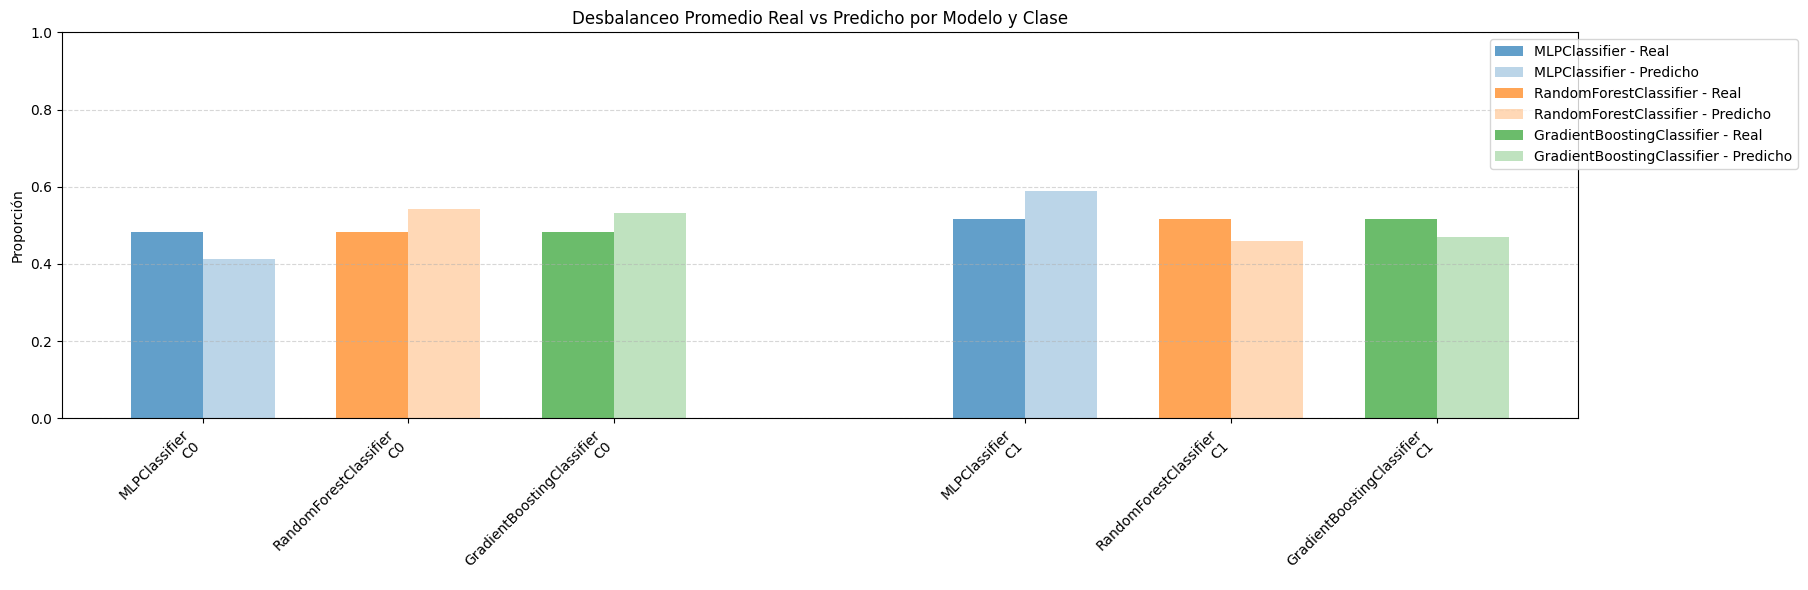

In [9]:
# Datos para el gráfico
model_names = list(desb_graf_dict.keys())
n_models = len(model_names)
bar_width = 0.35
spacing = 1.0  # espacio entre los grupos de clase 0 y clase 1

# Posiciones en el eje x
x_class_0 = np.arange(n_models)
x_class_1 = x_class_0 + n_models + spacing  # separado por un espacio

fig, ax = plt.subplots(figsize=(18, 6))

colors = plt.cm.tab10.colors  # paleta estándar de 10 colores

for idx, (model_name, data_graf) in enumerate(desb_graf_dict.items()):
    df = pd.DataFrame(data_graf)
    
    real_0 = df['real_0'].mean()
    pred_0 = df['pred_0'].mean()
    real_1 = df['real_1'].mean()
    pred_1 = df['pred_1'].mean()
    
    # barras clase 0
    ax.bar(x_class_0[idx], real_0, width=bar_width, label=f'{model_name} - Real', color=colors[idx], alpha=0.7)
    ax.bar(x_class_0[idx] + bar_width, pred_0, width=bar_width, label=f'{model_name} - Predicho', color=colors[idx], alpha=0.3)
    
    # barras clase 1
    ax.bar(x_class_1[idx], real_1, width=bar_width, color=colors[idx], alpha=0.7)
    ax.bar(x_class_1[idx] + bar_width, pred_1, width=bar_width, color=colors[idx], alpha=0.3)

# Etiquetas y ejes
ax.set_xticks(
    list(x_class_0 + bar_width / 2) + list(x_class_1 + bar_width / 2)
)
ax.set_xticklabels(
    [f'{name}\nC0' for name in model_names] + [f'{name}\nC1' for name in model_names],
    rotation=45, ha='right'
)
ax.set_ylabel('Proporción')
ax.set_title('Desbalanceo Promedio Real vs Predicho por Modelo y Clase')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_22964\548524735.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(models))  # tab10 da 10 colores distintos


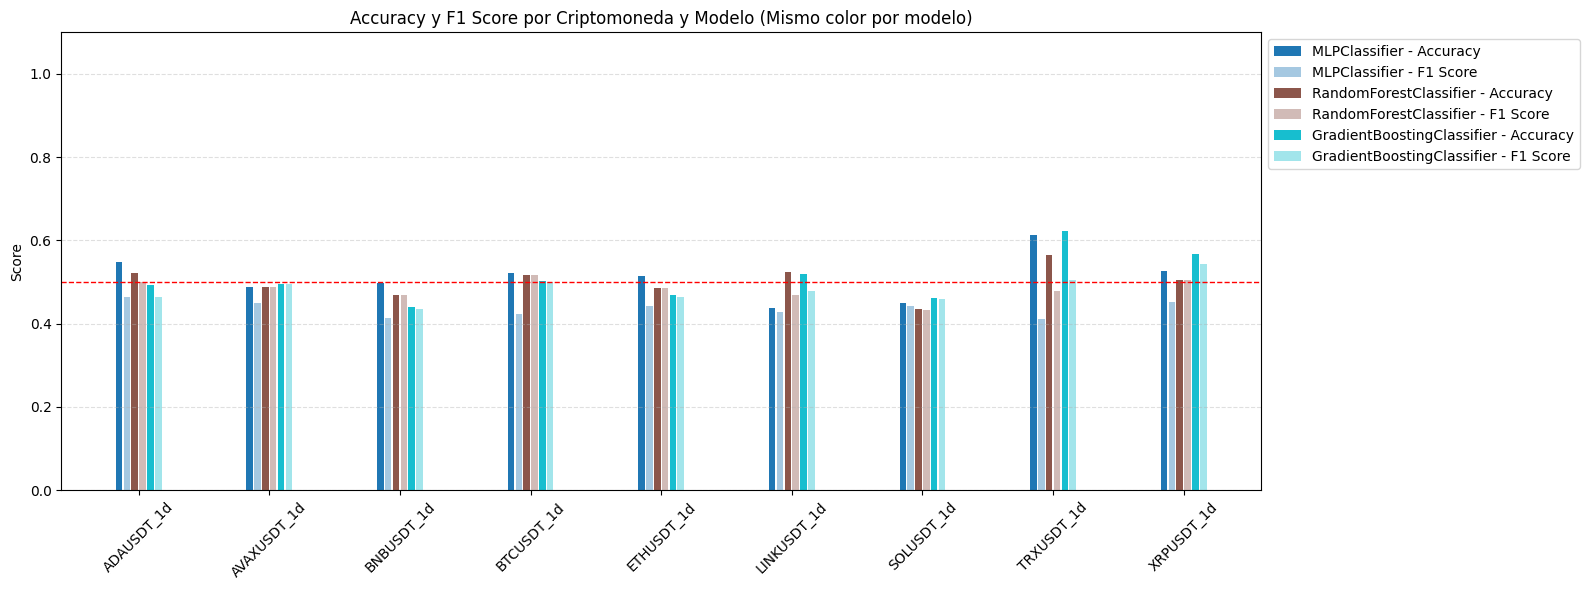

In [10]:
import matplotlib.cm as cm
df_all = []
for model_name, results in desb_graf_dict.items():
    df_model = pd.DataFrame({
        "crypto": results["crypto"],
        "acc": results["acc"],
        "f1": results["f1"],
        "model": model_name
    })
    df_all.append(df_model)

df = pd.concat(df_all, ignore_index=True)

# Preparar gráfico
cryptos = df["crypto"].unique()
models = df["model"].unique()
metrics = ["acc", "f1"]

fig, ax = plt.subplots(figsize=(16, 6))
bar_width = 0.05
x = np.arange(len(cryptos))

# Paleta de colores base por modelo
colors = cm.get_cmap('tab10', len(models))  # tab10 da 10 colores distintos

# Calcular desplazamientos
total_bars = len(models) * len(metrics)
offsets = np.linspace(-bar_width * total_bars / 2, bar_width * total_bars / 2, total_bars)

for i, model in enumerate(models):
    color_base = colors(i)
    for j, metric in enumerate(metrics):
        values = df[df["model"] == model].set_index("crypto").loc[cryptos][metric]
        alpha = 1.0 if metric == "acc" else 0.4  # Misma base de color, más claro para F1
        label = f"{model} - {'Accuracy' if metric == 'acc' else 'F1 Score'}"
        position = x + offsets[i * len(metrics) + j]
        ax.bar(position, values, width=bar_width, label=label, color=color_base, alpha=alpha)

# Ejes
ax.set_xticks(x)
ax.set_xticklabels(cryptos, rotation=45)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Accuracy y F1 Score por Criptomoneda y Modelo (Mismo color por modelo)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Límite 0.5')
plt.tight_layout()
plt.show()


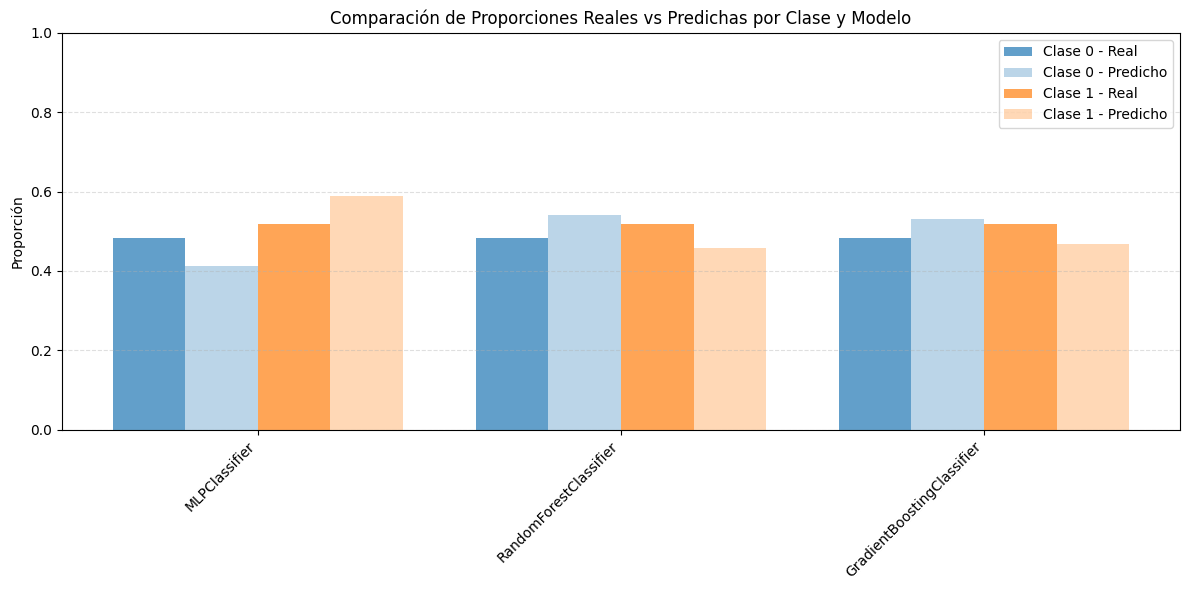

In [11]:
model_names = []
real_0, real_1, pred_0, pred_1 = [], [], [], []

for model, res in data_graf_dict.items():
    y_test = pd.Series(res["true"])
    y_pred = pd.Series(res["pred"])
    
    real_dist = y_test.value_counts(normalize=True).to_dict()
    pred_dist = y_pred.value_counts(normalize=True).to_dict()

    model_names.append(model)
    real_0.append(real_dist.get(0, 0))
    real_1.append(real_dist.get(1, 0))
    pred_0.append(pred_dist.get(0, 0))
    pred_1.append(pred_dist.get(1, 0))

# Posiciones para las barras
x = np.arange(len(model_names))
bar_width = 0.2

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - 1.5*bar_width, real_0, width=bar_width, label='Clase 0 - Real', color='tab:blue', alpha=0.7)
ax.bar(x - 0.5*bar_width, pred_0, width=bar_width, label='Clase 0 - Predicho', color='tab:blue', alpha=0.3)

ax.bar(x + 0.5*bar_width, real_1, width=bar_width, label='Clase 1 - Real', color='tab:orange', alpha=0.7)
ax.bar(x + 1.5*bar_width, pred_1, width=bar_width, label='Clase 1 - Predicho', color='tab:orange', alpha=0.3)

# Etiquetas y estilo
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Proporción')
ax.set_ylim(0, 1)
ax.set_title('Comparación de Proporciones Reales vs Predichas por Clase y Modelo')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()